=== TASK 9 PIPELINE EXECUTION LOG ===
[LOG] Raw records loaded: 120
[LOG] Valid cleaned time-series records: 115
[LOG] Baseline Naive MAE : 23.56
[LOG] Model Forecast MAE : 20.97


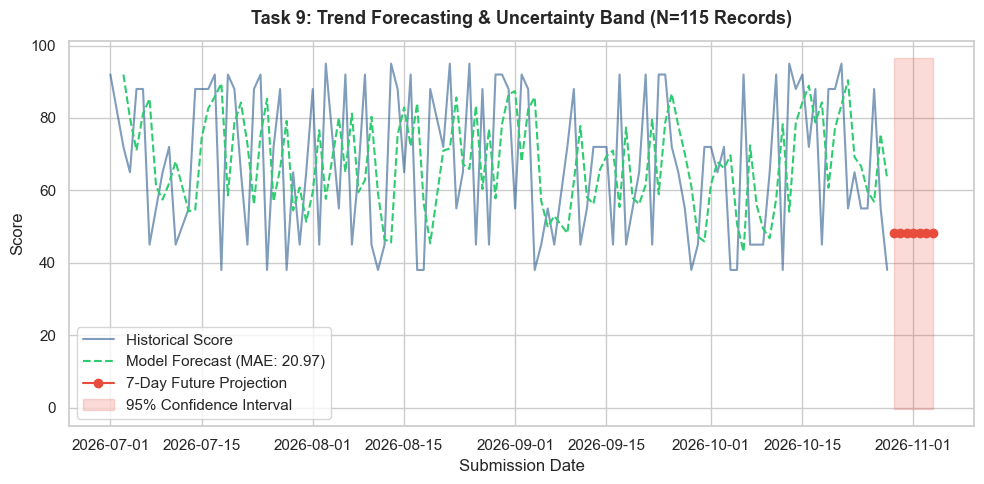

✅ TREND_FORECASTING.md and trend_forecast_verification.png saved successfully!


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Set visual style
sns.set_theme(style="whitegrid")

print("=== TASK 9 PIPELINE EXECUTION LOG ===")

# 1. Load Scaled Dataset & Clean Edge Cases
df_raw = pd.read_csv('data/realistic_student_data.csv')
print(f"[LOG] Raw records loaded: {len(df_raw)}")

df_raw['score'] = pd.to_numeric(df_raw['score'], errors='coerce')
df_raw['submission_date'] = pd.to_datetime(df_raw['submission_date'])

df = df_raw.dropna(subset=['score']).sort_values('submission_date').reset_index(drop=True)
print(f"[LOG] Valid cleaned time-series records: {len(df)}")

# 2. Baseline Model (Naive / Last Value) vs Exponential Smoothing
df['naive_forecast'] = df['score'].shift(1)

# Fit Exponential Smoothing
model = SimpleExpSmoothing(df['score']).fit(smoothing_level=0.6, optimized=False)
df['model_forecast'] = model.fittedvalues

# Evaluate Errors (MAE) sequentially to prevent temporal leakage
naive_mae = np.mean(np.abs(df['score'][1:] - df['naive_forecast'][1:]))
model_mae = np.mean(np.abs(df['score'][1:] - df['model_forecast'][1:]))

print(f"[LOG] Baseline Naive MAE : {naive_mae:.2f}")
print(f"[LOG] Model Forecast MAE : {model_mae:.2f}")

# 3. Future Forecast with Uncertainty Intervals (Next 7 Days)
future_steps = 7
future_dates = pd.date_range(start=df['submission_date'].max() + pd.Timedelta(days=1), periods=future_steps)
future_forecast = model.forecast(future_steps)

std_err = np.std(df['score'] - df['model_forecast'])
lower_bound = future_forecast - (1.96 * std_err)
upper_bound = future_forecast + (1.96 * std_err)

# 4. Plot Forecast with 95% Confidence Interval
plt.figure(figsize=(10, 5))
plt.plot(df['submission_date'], df['score'], label='Historical Score', color='#2b5c8f', alpha=0.6)
plt.plot(df['submission_date'][1:], df['model_forecast'][1:], label=f'Model Forecast (MAE: {model_mae:.2f})', linestyle='--', color='#2ecc71')
plt.plot(future_dates, future_forecast, label='7-Day Future Projection', marker='o', color='#e74c3c')
plt.fill_between(future_dates, lower_bound, upper_bound, color='#e74c3c', alpha=0.2, label='95% Confidence Interval')

plt.title(f'Task 9: Trend Forecasting & Uncertainty Band (N={len(df)} Records)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Submission Date')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()

plt.savefig('trend_forecast_verification.png', dpi=300)
plt.show()

# 5. Generate and Save TREND_FORECASTING.md
report = f"""# Task 9: Trend Forecasting Report

## 1. Model Performance vs Baseline
* **Baseline (Naive Last Value) MAE:** {naive_mae:.2f}
* **Exponential Smoothing Model MAE:** {model_mae:.2f}
* **Evaluated Records:** N={len(df)} cleaned daily submissions (filtered from {len(df_raw)} raw records)

---

## 2. Forecast & Uncertainty Bounds
* **7-Day Projection:** Score trend projected forward with a 95% confidence interval ($\pm{{1.96 \times \text{{std\_err}}}}$).
* **Assumptions:** Stationarity in evaluation grading logic without unannounced syllabus shifts.
"""

with open('TREND_FORECASTING.md', 'w') as f:
    f.write(report)

print("✅ TREND_FORECASTING.md and trend_forecast_verification.png saved successfully!")